In [ ]:
import pandas as pd
import spacy
nlp = spacy.load('en_core_web_sm')
import time
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MSDA683/FinalProject/bank_reviews3.csv')

In [ ]:
df.head()

,author,date,address,bank,rating,review_title_by_user,review,bank_image,rating_title_by_user,useful_count
0,AMRENDRA T,"Mar 21, 2020",New delhi,SBI,4.0,"""Best saving""",State Bank Of India is located nearby in our a...,https://static.bankbazaar.com/images/common/ba...,Great!,133
1,BISHWA,"Mar 20, 2020",Kolkata,SBI,5.0,"""Good service""","I have my salary account in SBI, when I applie...",https://static.bankbazaar.com/images/common/ba...,Blown Away!,89
2,SANTOSH,"Mar 20, 2020",Hooghly,Axis Bank,5.0,"""Excellent Service""",I am using Axis bank saving account for the p...,https://static.bankbazaar.com/images/common/ba...,Blown Away!,48
3,MAHADEV,"Mar 20, 2020",Pune,HDFC Bank,5.0,"""Excellent service""",I have my salary bank account in HDFC bank for...,https://static.bankbazaar.com/images/common/ba...,Blown Away!,52
4,R,"Mar 20, 2020",Bangalore,review,5.0,"""Good account""","Close to around 10 years, I am holding this Co...",https://static.bankbazaar.com/images/common/ba...,Blown Away!,22


In [ ]:
print(df.keys())

Index(['author', 'date', 'address', 'bank', 'rating', 'review_title_by_user',
       'review', 'bank_image', 'rating_title_by_user', 'useful_count'],
      dtype='object')


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   author                996 non-null    object 
 1   date                  1000 non-null   object 
 2   address               1000 non-null   object 
 3   bank                  1000 non-null   object 
 4   rating                1000 non-null   float64
 5   review_title_by_user  1000 non-null   object 
 6   review                1000 non-null   object 
 7   bank_image            1000 non-null   object 
 8   rating_title_by_user  1000 non-null   object 
 9   useful_count          1000 non-null   int64  
dtypes: float64(1), int64(1), object(8)
memory usage: 78.3+ KB


In [ ]:
bankrating_df = pd.DataFrame(df, columns=['bank','rating','review'])
print(bankrating_df.shape)
bankrating_df.head()

(1000, 3)


,bank,rating,review
0,SBI,4.0,State Bank Of India is located nearby in our a...
1,SBI,5.0,"I have my salary account in SBI, when I applie..."
2,Axis Bank,5.0,I am using Axis bank saving account for the p...
3,HDFC Bank,5.0,I have my salary bank account in HDFC bank for...
4,review,5.0,"Close to around 10 years, I am holding this Co..."


In [ ]:
print(bankrating_df.keys())

Index(['bank', 'rating', 'review'], dtype='object')


In [ ]:
bankrating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   bank    1000 non-null   object 
 1   rating  1000 non-null   float64
 2   review  1000 non-null   object 
dtypes: float64(1), object(2)
memory usage: 23.6+ KB


In [ ]:
bankrating_df.rating.value_counts()

,count
rating,
5.0,550
4.0,257
3.0,71
4.5,45
2.0,30
3.5,21
1.0,13
0.5,10
2.5,2


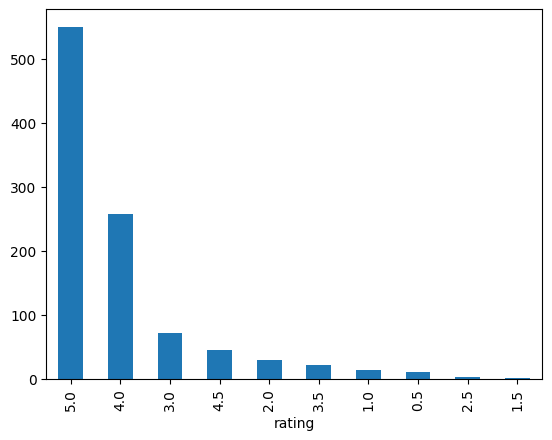

In [ ]:
bankrating_df.rating.value_counts().plot(kind='bar')
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/bankratingcounts.jpg', bbox_inches='tight')

In [ ]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

bankrating_df['review'] = bankrating_df['review'].apply(lambda text: remove_urls(text))
bankrating_df.head()

,bank,rating,review
0,SBI,4.0,State Bank Of India is located nearby in our a...
1,SBI,5.0,"I have my salary account in SBI, when I applie..."
2,Axis Bank,5.0,I am using Axis bank saving account for the p...
3,HDFC Bank,5.0,I have my salary bank account in HDFC bank for...
4,review,5.0,"Close to around 10 years, I am holding this Co..."


In [ ]:
import string
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

bankrating_df['review'] = bankrating_df['review'].apply(lambda text: remove_punctuation(text))
bankrating_df.head()

,bank,rating,review
0,SBI,4.0,State Bank Of India is located nearby in our a...
1,SBI,5.0,I have my salary account in SBI when I applied...
2,Axis Bank,5.0,I am using Axis bank saving account for the p...
3,HDFC Bank,5.0,I have my salary bank account in HDFC bank for...
4,review,5.0,Close to around 10 years I am holding this Cor...


In [ ]:
bankfiveStardf = bankrating_df[df['rating'] == 5]


In [ ]:
bankfiveStardf.head()

,bank,rating,review
1,SBI,5.0,I have my salary account in SBI when I applied...
2,Axis Bank,5.0,I am using Axis bank saving account for the p...
3,HDFC Bank,5.0,I have my salary bank account in HDFC bank for...
4,review,5.0,Close to around 10 years I am holding this Cor...
5,IDBI,5.0,I am not getting an alert message from IDBI ba...


In [ ]:
bankfiveStarSamp = bankfiveStardf.sample(n=550)
bankfiveStarSamp.shape

(550, 3)

In [ ]:
start_time = time.perf_counter()
FiveStarAdj = []
FiveStarProds = []
for index, row in bankfiveStarSamp.iterrows():
  doc = nlp(row['review'])
  for ent in doc.ents:
    if ent.label_ == 'PRODUCT':
      FiveStarProds.append(str(ent).lower().capitalize())
  for token in doc:
    if token.pos_ == 'ADJ':
      FiveStarAdj.append(str(token).capitalize())
end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(FiveStarProds)} brands mentioned in {len(bankfiveStarSamp)} reviews" )

Elapsed time: 10.469373735000033 seconds
Found 4 brands mentioned in 550 reviews


In [ ]:
 sorted_bank_Prodlist = sorted(FiveStarProds, key=str)
 top_bank_Prodlist = pd.DataFrame(Counter(sorted_bank_Prodlist).most_common(20), columns=['Product','Count'])
 print(top_bank_Prodlist)

  Product  Count
0   3500k      1
1    Neft      1
2  Rs5000      1
3  Salary      1


In [ ]:
final_list = top_bank_Prodlist

In [ ]:
final_list = final_list.drop(index=3)

In [ ]:
print(final_list)

  Product  Count
0   3500k      1
1    Neft      1
2  Rs5000      1


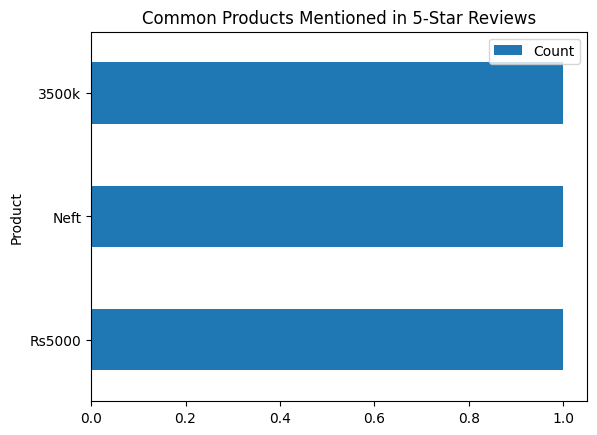

In [ ]:
plot = final_list.plot.barh(x='Product', y='Count',
                            title='Common Products Mentioned in 5-Star Reviews').invert_yaxis()
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/commonproducts5starbanks.jpg', bbox_inches='tight')

In [ ]:
sorted_bank_Adjlist = sorted(FiveStarAdj, key=str)
top_bank_Adjlist = pd.DataFrame(Counter(sorted_bank_Adjlist).most_common(20), columns=['Adjective','Count'])
print(top_bank_Adjlist)

      Adjective  Count
0          Good    342
1       Minimum    264
2           Net    214
3        Mobile    205
4          More    174
5          Past    117
6      Friendly    112
7        Hidden     82
8         Alert     79
9    Applicable     63
10        Other     62
11         Easy     46
12       Online     40
13         Near     37
14         Last     34
15         Safe     34
16    Satisfied     31
17    Available     29
18  Comfortable     26
19         Fine     26


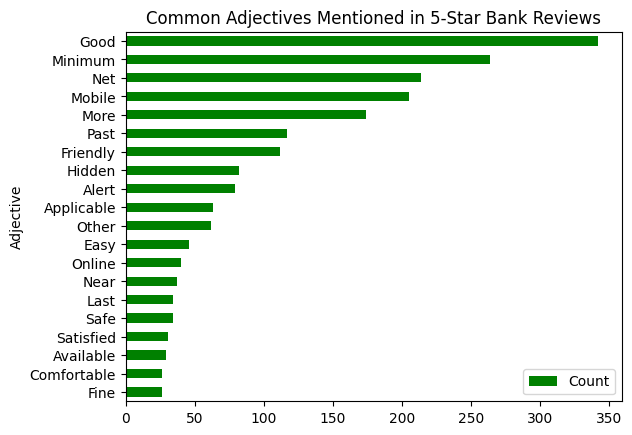

In [ ]:
plot = top_bank_Adjlist.plot.barh(x='Adjective', y='Count', color = 'green',
                            title='Common Adjectives Mentioned in 5-Star Bank Reviews').invert_yaxis()
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/5starBANKADJ.jpg', bbox_inches='tight')

In [ ]:
start_time = time.perf_counter()
bankFiveStarAdjOne = []
for index, row in bankfiveStarSamp.iterrows():
  doc = nlp(row['review'])
  for ent in doc.ents:
    if ent.label_ == 'PRODUCT' and str(ent).lower() == "app":
      for token in doc:
        if token.pos_ == 'ADJ':
          bankFiveStarAdjOne.append(str(token).capitalize())
end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(bankFiveStarAdjOne)

Elapsed time: 10.063885981000112 seconds
[]


In [ ]:
sorted_bank_AdjlistOne = sorted(bankFiveStarAdjOne, key=str)
top_bank_AdjlistOne = pd.DataFrame(Counter(sorted_bank_AdjlistOne).most_common(20), columns=['Adjective','Count'])
print(top_bank_AdjlistOne)

Empty DataFrame
Columns: [Adjective, Count]
Index: []


In [ ]:
start_time = time.perf_counter()
mobile_related_nouns = []

for index, row in bankfiveStarSamp.iterrows():
    doc = nlp(row['review'])
    mobile_token_indices = [token.i for token in doc if token.text.lower() == "mobile"]

    for mobile_index in mobile_token_indices:
        for token in doc[max(0, mobile_index - 5) : min(len(doc), mobile_index + 6)]:
            if token.pos_ == 'NOUN':
                mobile_related_nouns.append(str(token).capitalize())

end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(mobile_related_nouns)} mobile-related nouns in {len(bankfiveStarSamp)} reviews" )

Elapsed time: 10.041017691999969 seconds
Found 794 mobile-related nouns in 550 reviews


In [ ]:
sorted_mobile_nouns = sorted(mobile_related_nouns, key=str)
top_mobile_nouns = pd.DataFrame(Counter(sorted_mobile_nouns).most_common(20), columns=['Noun','Count'])
print(top_mobile_nouns)

           Noun  Count
0       Banking    237
1           App    159
2       Service    101
3      Facility     56
4      Internet     34
5       Balance     30
6       Account     27
7          User     22
8          Bank     16
9        Mobile     10
10  Application      7
11       Rupees      6
12        Years      6
13       Branch      5
14      Charges      5
15         Time      4
16  Transaction      4
17     Transfer      4
18     Branches      3
19      Branchs      3


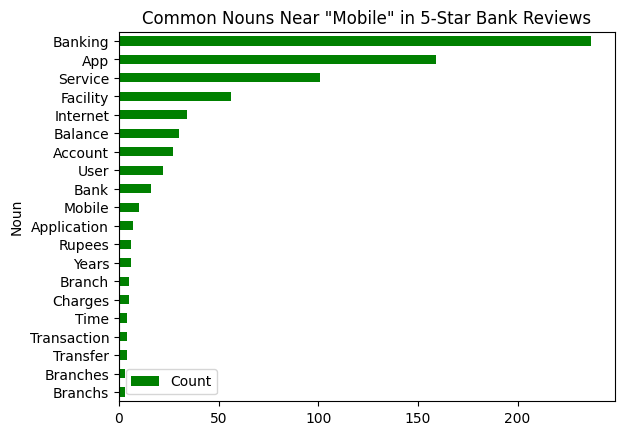

In [ ]:
if not top_mobile_nouns.empty:
    plot = top_mobile_nouns.plot.barh(x='Noun', y='Count', color = 'green',
                                title='Common Nouns Near "Mobile" in 5-Star Bank Reviews').invert_yaxis()
    plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/mobile_related_nouns_5star.jpg', bbox_inches='tight')
else:
    print("mobile-related nouns")

In [ ]:
start_time = time.perf_counter()
app_related_adjectives = []

for index, row in bankfiveStarSamp.iterrows():
    doc = nlp(row['review'])
    app_token_indices = [token.i for token in doc if token.text.lower() == "app"]

    for app_index in app_token_indices:
        # Look for adjectives in the surrounding 5 tokens (adjust window size as needed)
        for token in doc[max(0, app_index - 5) : min(len(doc), app_index + 6)]:
            if token.pos_ == 'ADJ':
                app_related_adjectives.append(str(token).capitalize())

end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(app_related_adjectives)} app-related adjectives in {len(bankfiveStarSamp)} reviews" )

Elapsed time: 10.936294150999856 seconds
Found 315 app-related adjectives in 550 reviews


In [ ]:
sorted_app_adjectives = sorted(app_related_adjectives, key=str)
top_app_adjectives = pd.DataFrame(Counter(sorted_app_adjectives).most_common(20), columns=['Adjective','Count'])
print(top_app_adjectives)

      Adjective  Count
0        Mobile    135
1           Net     77
2          Good     22
3      Friendly     19
4          Easy     12
5        Online      6
6   Comfortable      5
7    Convenient      4
8    Additional      3
9    Applicable      3
10    Available      2
11       Better      2
12         Free      2
13      Minimum      2
14         Most      2
15         Past      2
16       Useful      2
17       Annual      1
18      Awesome      1
19         Fine      1


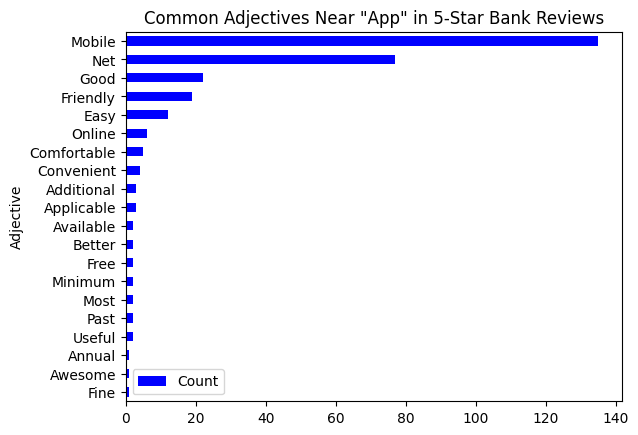

In [ ]:
if not top_app_adjectives.empty:
    plot = top_app_adjectives.plot.barh(x='Adjective', y='Count', color = 'blue',
                                title='Common Adjectives Near "App" in 5-Star Bank Reviews').invert_yaxis()
    plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/app_related_adjectives_5star.jpg', bbox_inches='tight')

                                              review sentiment
0  State Bank Of India is located nearby in our a...  positive
1  I have my salary account in SBI when I applied...  positive
2  I am using Axis bank saving account for the  p...  positive
3  I have my salary bank account in HDFC bank for...  positive
4  Close to around 10 years I am holding this Cor...  positive
sentiment
positive    879
negative    106
neutral      15
Name: count, dtype: int64


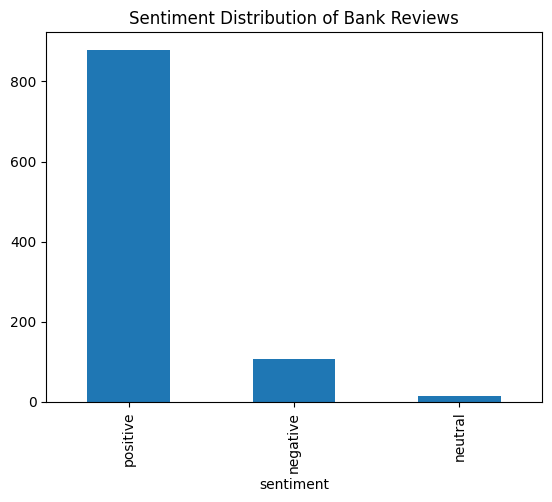

In [ ]:
!pip install textblob

from textblob import TextBlob

def get_sentiment(text):
    '''
    Utility function to classify sentiment of passed tweet
    using textblob's sentiment method
    '''
    # create TextBlob object of passed tweet text
    analysis = TextBlob(text)
    # set sentiment
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity == 0:
        return 'neutral'
    else:
        return 'negative'

bankrating_df['sentiment'] = bankrating_df['review'].apply(get_sentiment)

print(bankrating_df[['review', 'sentiment']].head())

print(bankrating_df['sentiment'].value_counts())

bankrating_df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution of Bank Reviews')
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/sentiment_distribution.jpg', bbox_inches='tight')
plt.show()


Sentiment analysis for reviews mentioning 'mobile' or 'app':
                                               review sentiment
1   I have my salary account in SBI when I applied...  positive
2   I am using Axis bank saving account for the  p...  positive
10  I came to know that there is trial of 0 charge...  positive
16  I am holding a salary account with AXIS bank p...  positive
18  Since 14 years I am using Oriental Bank saving...  positive

Sentiment distribution for reviews mentioning 'mobile' or 'app':
sentiment
positive    478
negative     53
neutral       2
Name: count, dtype: int64


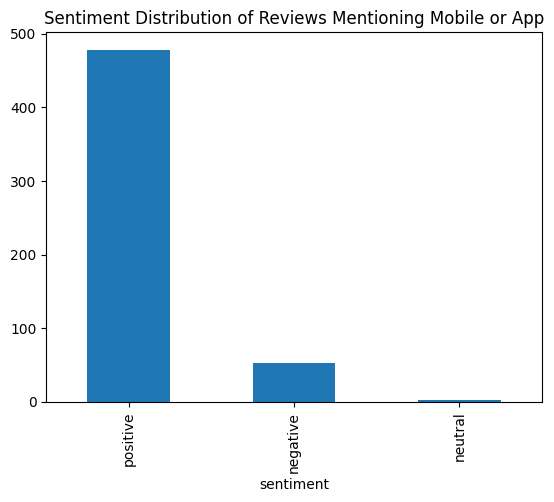

In [ ]:
# prompt: create sentiment analysis of reviews that mention mobile or app

# Filter reviews that mention 'mobile' or 'app'
mobile_app_reviews_df = bankrating_df[
    bankrating_df['review'].str.contains('mobile|app', case=False, na=False)
].copy()

# Apply sentiment analysis to the filtered reviews
mobile_app_reviews_df['sentiment'] = mobile_app_reviews_df['review'].apply(get_sentiment)

print("\nSentiment analysis for reviews mentioning 'mobile' or 'app':")
print(mobile_app_reviews_df[['review', 'sentiment']].head())

print("\nSentiment distribution for reviews mentioning 'mobile' or 'app':")
print(mobile_app_reviews_df['sentiment'].value_counts())

# Plot the sentiment distribution for these filtered reviews
mobile_app_reviews_df['sentiment'].value_counts().plot(
    kind='bar', title='Sentiment Distribution of Reviews Mentioning Mobile or App'
)
plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/mobile_app_sentiment_distribution.jpg', bbox_inches='tight')
plt.show()

Elapsed time: 1.8703667690001566 seconds
Found 465 adjectives in 106 negative reviews

Top 20 Adjectives in Negative Sentiment Reviews:
     Adjective  Count
0      Minimum     55
1         Past     33
2        Other     27
3          Net     24
4   Applicable     20
5       Mobile     18
6       Hidden     15
7       Proper     14
8         Good     11
9        Alert     10
10    Previous     10
11        Last      9
12        Much      8
13      Prompt      8
14   Satisfied      8
15        More      7
16     Average      6
17     Monthly      6
18      Annual      5
19        Long      5


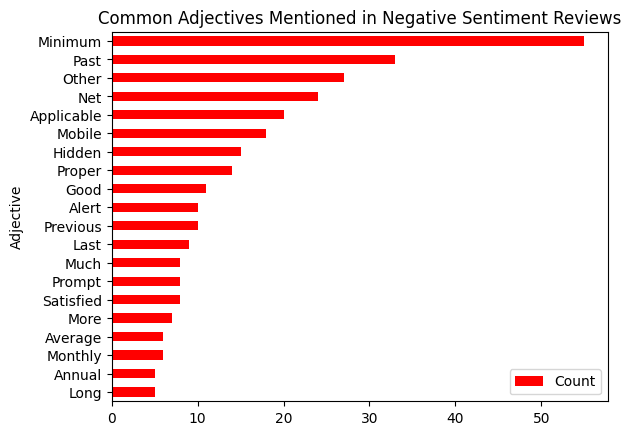

In [ ]:
# prompt: top 20 adjectives used in negative sentiment reviews along with their counts

# Filter for negative sentiment reviews
negative_reviews_df = bankrating_df[bankrating_df['sentiment'] == 'negative'].copy()

# Extract adjectives from negative reviews
start_time = time.perf_counter()
negative_adjectives = []
for index, row in negative_reviews_df.iterrows():
    doc = nlp(row['review'])
    for token in doc:
        if token.pos_ == 'ADJ':
            negative_adjectives.append(str(token).capitalize())

end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(negative_adjectives)} adjectives in {len(negative_reviews_df)} negative reviews" )

# Count the occurrences of each adjective and get the top 20
sorted_negative_adjectives = sorted(negative_adjectives, key=str)
top_negative_adjectives = pd.DataFrame(
    Counter(sorted_negative_adjectives).most_common(20),
    columns=['Adjective','Count']
)

print("\nTop 20 Adjectives in Negative Sentiment Reviews:")
print(top_negative_adjectives)

# Plot the top 20 negative adjectives
if not top_negative_adjectives.empty:
    plot = top_negative_adjectives.plot.barh(
        x='Adjective',
        y='Count',
        color = 'red',
        title='Common Adjectives Mentioned in Negative Sentiment Reviews'
    ).invert_yaxis()
    plt.savefig('/content/drive/MyDrive/MSDA683/FinalProject/negative_adjectives.jpg', bbox_inches='tight')
    plt.show()
else:
    print("No adjectives found in negative reviews.")

In [ ]:
negative_mobile_app_reviews_df = mobile_app_reviews_df[mobile_app_reviews_df['sentiment'] == 'negative'].copy()

print("\nNegative Sentiment Reviews mentioning 'mobile' or 'app':")
negative_mobile_app_reviews_df



Negative Sentiment Reviews mentioning 'mobile' or 'app':


,bank,rating,review,sentiment
28,SBI,3.0,I have been using saving account with SBI for ...,negative
44,review,5.0,For cash withdrawal i am getting instantly ale...,negative
53,review,3.0,I have been with Standard chartered Bank for p...,negative
73,review,5.0,More than 20 years i have been using the salar...,negative
74,Axis Bank,0.5,Axis bank has limited options in menu of Custo...,negative
92,review,3.0,I am holding my salary account with Bank of ...,negative
104,HDFC Bank,5.0,I am holding salary account with HDFC past 1 y...,negative
119,Axis Bank,4.0,AXIS has provided a chance to open a salary ac...,negative
122,review,5.0,On my personal need I opened a saving account ...,negative
127,review,5.0,When I was working in previous company they t...,negative


In [ ]:
negative_mobile_app_reviews_df.to_csv('/content/drive/MyDrive/MSDA683/FinalProject/negative_mobile_app_reviews.csv', index=False)
print("\nSaved negative mobile/app reviews to 'negative_mobile_app_reviews.csv'")


Saved negative mobile/app reviews to 'negative_mobile_app_reviews.csv'
